# Tutorial 5: Rigorous Estimation and Bias Correction

In Tutorial 1 we saw that MI estimates are unreliable at small sample sizes.
In Tutorial 4 we saw how to find good parameters using sweeps. But even with
good parameters, a single `mode='estimate'` call has two problems that make it
unsuitable for scientific reporting:

1. **No error bar.** A single number with no uncertainty estimate is not a
   scientific result — it is a point estimate that could be anywhere within
   a wide confidence interval.

2. **Finite-sample bias.** With limited data the estimate is systematically off,
   and two effects *compete*: the classical limited-sampling bias inflates
   apparent MI (finite samples manufacture spurious dependence), while the neural
   *lower-bound* estimator under-shoots when its critic is under-trained on little
   data. Which one wins is regime-dependent — and that ambiguity is exactly why a
   single small-sample estimate is untrustworthy — but the deviation scales
   systematically as $O(1/N)$ in the sample size.

`mode='rigorous'` turns that systematic $O(1/N)$ dependence into a correction. It
trains models on progressively smaller subsets of the data, measures how the
estimate moves as sample size shrinks (in *whichever* direction), and extrapolates
to the infinite-data limit. The result is a **bias-corrected MI estimate with a
confidence interval** — a result you can report in a paper.

This tutorial demonstrates the problem, the solution, and how to recognise when
the solution itself is not reliable.

## 1. Setup: Nonlinear Data with Known MI

We use `nmi.generators.generate_nonlinear_from_latent` to create two
high-dimensional variables that share a nonlinear relationship through a
low-dimensional latent variable. We do so by using the correlated Gaussians in Tutorial 1
where there is a closed-form analytical relationship between correlation and MI, then 
we use a frozen neural network that takes the latent variables to the observable on, 
making it a harder estimation problem because of the nonlinearity, but since the neural net
can be approximated as a "sufficently smooth" function, the MI roughly stays the same.

We set the ground truth MI to **3.0 bits** spread over 10 dimensions 
and use a moderate sample size (2000 samples) that are embedded nonlinearly
 in 100 dimensional space — small enough that the finite-sample bias is 
 clearly visible and does a poor job to sample the apparent 100 dimensions,
  but large enough to sample the latent ones.

Because each sample is drawn independently (IID), we leave `processing` unset
and use `Split(mode='random')`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neural_mi as nmi

sns.set_context("talk")
np.random.seed(42)

ground_truth_mi = 3.0
n_samples = 2000

x, y = nmi.generators.generate_nonlinear_from_latent(
    n_samples=n_samples,
    latent_dim=10,
    observed_dim=100,
    mi=ground_truth_mi,
)

print(f"X shape: {x.shape}  (n_samples, observed_dim)")
print(f"Y shape: {y.shape}  (n_samples, observed_dim)")
print(f"Ground truth MI: {ground_truth_mi} bits")

X shape: torch.Size([2000, 100])  (n_samples, observed_dim)
Y shape: torch.Size([2000, 100])  (n_samples, observed_dim)
Ground truth MI: 3.0 bits


## 2. The Problem: Bias and Variance of Naive Estimates

Before running `mode='rigorous'`, let's make the problem concrete. We will run
`mode='estimate'` on different-sized subsets of the data to watch how the
estimate moves — and how noisy it becomes — as the sample size shrinks. This is
the finite-sample regime in action.

In [2]:
model = nmi.Model(hidden_dim=128, embedding_dim=64)
training = nmi.Training(n_epochs=100, patience=20)

sample_fractions = [1.0, 0.5, 0.25, 0.1]
naive_estimates = {}

print("--- Demonstrating finite-sample bias ---")
for frac in sample_fractions:
    n = int(n_samples * frac)
    r = nmi.run(
        x[:n], y[:n],
        mode='estimate',
        split=nmi.Split(mode='random'),  # IID data: random split is correct
        model=model, training=training,
    )
    naive_estimates[n] = r.mi_estimate
    print(f"  n={n:5d} samples  →  MI = {r.mi_estimate:.3f} bits  "
          f"(bias = {r.mi_estimate - ground_truth_mi:+.3f} bits)")

print(f"\nGround truth: {ground_truth_mi:.3f} bits")

--- Demonstrating finite-sample bias ---


Run 2ad7ffdd-0ba2-401c-ae11-8f61c7002c3d_c0:   0%|          | 0/100 [00:00<?, ?it/s]

  n= 2000 samples  →  MI = 2.883 bits  (bias = -0.117 bits)


Run dfa8d9ab-d707-41f2-8897-778d9957156b_c0:   0%|          | 0/100 [00:00<?, ?it/s]

  n= 1000 samples  →  MI = 3.152 bits  (bias = +0.152 bits)


Run de90debd-2f20-4c97-a71e-3dd543c1300d_c0:   0%|          | 0/100 [00:00<?, ?it/s]

  n=  500 samples  →  MI = 2.753 bits  (bias = -0.247 bits)


Run 6e4217ca-2a83-4f20-b621-60488c1bbf03_c0:   0%|          | 0/100 [00:00<?, ?it/s]

  n=  200 samples  →  MI = 2.867 bits  (bias = -0.133 bits)

Ground truth: 3.000 bits


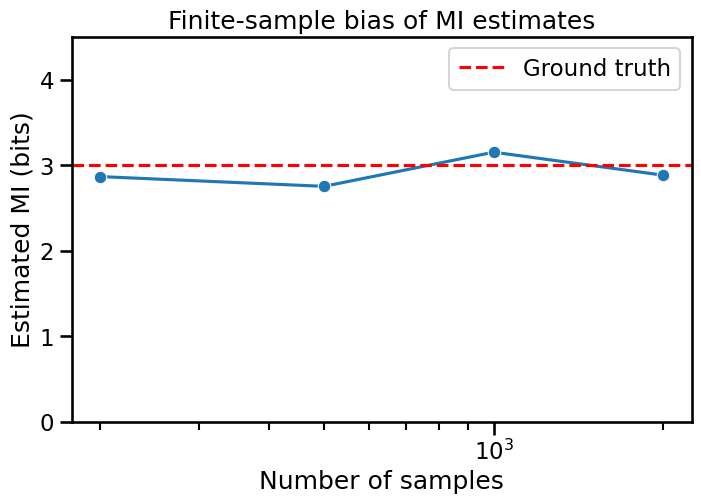

In [3]:
# plot the naive estimates
plt.figure(figsize=(8, 5))
ax = sns.lineplot(x=list(naive_estimates.keys()), y=list(naive_estimates.values()), marker='o')
ax.axhline(ground_truth_mi, color='red', linestyle='--', label="Ground truth")
ax.set_xscale('log')
ax.set_xlabel("Number of samples")
ax.set_ylabel("Estimated MI (bits)")
ax.set_title("Finite-sample bias of MI estimates")
ax.legend()
plt.ylim(0, ground_truth_mi * 1.5)
plt.show()

As the sample size changes the estimated MI moves around, and from a single
value we cannot tell how much of that movement is a finite-sampling effect. With
only 10% of the data the estimate can land well above *or* below the ground
truth: classical limited-sampling tends to inflate it, an under-trained
lower-bound critic tends to deflate it, and the variance is large either way. You
can see this by running the previous block a few times — the numbers jump around.

The practical consequence is that a naive estimate on your full dataset sits
*somewhere* near the true MI — but you do not know on which side, or by how much,
without a correction procedure.

## 3. The Solution: `mode='rigorous'`

`mode='rigorous'` exploits the systematic relationship between sample size and
bias that we just observed. It works as follows:

1. **Subset training.** The full dataset of $N$ samples is divided into $\gamma$
   equal parts, and a model is trained on one part (i.e. on $N/\gamma$ samples).
   This is repeated for $\gamma = 1, 2, 3, \ldots, 10$ (by default), with
   multiple independent runs at each $\gamma$.

2. **Bias as a function of $\gamma$.** The estimated MI at each $\gamma$ is
   plotted against $\gamma$. Because the finite-sample deviation scales as
   $O(1/N) = O(\gamma/N)$, this relationship is approximately **linear in
   $\gamma$** — the estimate moves systematically (up *or* down) as $\gamma$
   grows and each model sees less data.

3. **Extrapolation to infinite data.** A weighted linear fit to the linear region
   of the MI-vs-$\gamma$ curve is extrapolated to $\gamma = 0$ (the infinite-data
   limit). The y-intercept of this fit is the **bias-corrected MI estimate**, and
   the uncertainty of the fit gives the **confidence interval**.

By default, `mode='rigorous'` runs $\gamma = 1$ through $10$, with $\gamma$
independent runs at each level — giving $1 + 2 + \cdots + 10 = 55$ total training
runs. This is why `n_workers > 1` is strongly recommended.

**Why subsample-and-extrapolate (rather than bootstrap)?** This procedure adapts
the classical MI-bias-correction program to neural estimators, following
Abdelaleem et al. (2025, *Accurate estimation of mutual information in high
dimensional data*, arXiv:2506.00330). Crucially, the confidence interval comes
from the fit across independent subsamples of increasing size; a naive bootstrap
would give the *wrong* interval here, because resampled subsets are not
independent (see Holmes & Nemenman, 2019, for the analogous argument in the
KSG-estimator setting).

In [4]:
# First, store the naive estimate on the full dataset for comparison later
naive_full = naive_estimates[n_samples]

print("Running mode='rigorous' — 55 training runs by default.")
print("Using n_workers=4 to parallelise. This may take a few minutes...\n")

rigorous_results = nmi.run(
    x, y,
    mode='rigorous',
    split=nmi.Split(mode='random'),      # IID data: random split is correct
    model=model, training=training,
    n_workers=4,              # strongly recommended for rigorous mode
)

mi_corrected  = rigorous_results.mi_estimate
# mi_error     = confidence-interval half-width on the *fitted mean* of the
#                extrapolation.  Use this for scientific reporting.
# mi_error_pred = prediction-interval half-width — more conservative; covers
#                 where a *new individual estimate* would land.  Always >= mi_error.
mi_error      = rigorous_results.details['mi_error']
mi_error_pred = rigorous_results.details.get('mi_error_pred', None)
is_reliable   = rigorous_results.details['is_reliable']

print(f"--- Rigorous Results ---")
print(f"Ground truth MI:           {ground_truth_mi:.3f} bits")
print(f"Naive estimate (full N):   {naive_full:.3f} bits")
print(f"Corrected MI estimate:     {mi_corrected:.3f} ± {mi_error:.3f} bits  (CI half-width)")
if mi_error_pred is not None:
    print(f"Prediction interval:       {mi_corrected:.3f} ± {mi_error_pred:.3f} bits  (PI half-width)")
print(f"Fit is reliable:           {is_reliable}")

2026-07-12 13:49:56 - neural_mi - WARNING - gamma=3: smallest data subset has 666 samples (threshold: 1000). MI estimates at this gamma may be unreliable. Consider reducing gamma_range or collecting more data. Set 'min_reliable_samples' in base_params to adjust this threshold.


2026-07-12 13:49:56 - neural_mi - WARNING - gamma=4: smallest data subset has 500 samples (threshold: 1000). MI estimates at this gamma may be unreliable. Consider reducing gamma_range or collecting more data. Set 'min_reliable_samples' in base_params to adjust this threshold.


2026-07-12 13:49:56 - neural_mi - WARNING - gamma=5: smallest data subset has 400 samples (threshold: 1000). MI estimates at this gamma may be unreliable. Consider reducing gamma_range or collecting more data. Set 'min_reliable_samples' in base_params to adjust this threshold.


2026-07-12 13:49:56 - neural_mi - WARNING - gamma=6: smallest data subset has 333 samples (threshold: 1000). MI estimates at this gamma may be unreliable. Consider reducing gamma_range or collecting more data. Set 'min_reliable_samples' in base_params to adjust this threshold.


2026-07-12 13:49:56 - neural_mi - WARNING - gamma=7: smallest data subset has 285 samples (threshold: 1000). MI estimates at this gamma may be unreliable. Consider reducing gamma_range or collecting more data. Set 'min_reliable_samples' in base_params to adjust this threshold.


...

Run 48fabe79-c1eb-466d-9fd7-11b6929b1ec3_c0_g10_s8 | MI: 1.220:  64%|██████▍   | 64/100 [00:01<00:00, 51.46it/s]

Run 48fabe79-c1eb-466d-9fd7-11b6929b1ec3_c0_g10_s9 | MI: 1.095:  77%|███████▋  | 77/100 [00:01<00:00, 54.16it/s]

Run 48fabe79-c1eb-466d-9fd7-11b6929b1ec3_c0_g10_s8 | MI: 1.232:  88%|████████▊ | 88/100 [00:02<00:00, 53.71it/s]

Run 48fabe79-c1eb-466d-9fd7-11b6929b1ec3_c0_g10_s8 | MI: 1.407:  94%|█████████▍| 94/100 [00:02<00:00, 53.74it/s]

--- Rigorous Results ---
Ground truth MI:           3.000 bits
Naive estimate (full N):   2.883 bits
Corrected MI estimate:     3.064 ± 0.088 bits  (CI half-width)
Prediction interval:       3.064 ± 0.156 bits  (PI half-width)
Fit is reliable:           True


## 4. Visualising the Correction

The `results.plot()` method produces the canonical rigorous-mode figure.
Let's walk through what each element means before generating it:

- **X-axis ($\gamma$):** The number of equal parts the data was split into.
  At $\gamma = 1$, the model trained on all the data. At $\gamma = 10$,
  it trained on only one tenth.
- **Grey dots:** Individual MI estimates from each training run. There are
  $\gamma$ dots at each $\gamma$ value (one per independent run).
- **Black line:** The mean MI estimate at each $\gamma$. Watch how it moves as
  $\gamma$ increases (it drifts as each model sees less data) — this systematic
  trend, in whichever direction it runs, is the finite-sample dependence we correct.
- **Red dashed line:** The weighted linear fit to the linear region of the
  black curve, extrapolated back to $\gamma = 1$ and forward to the y-axis.
- **Red star at $\gamma = 0$:** The y-intercept — our bias-corrected estimate,
  with error bars from the fit uncertainty.

We also annotate the plot with the naive estimate so the correction magnitude
is immediately visible.

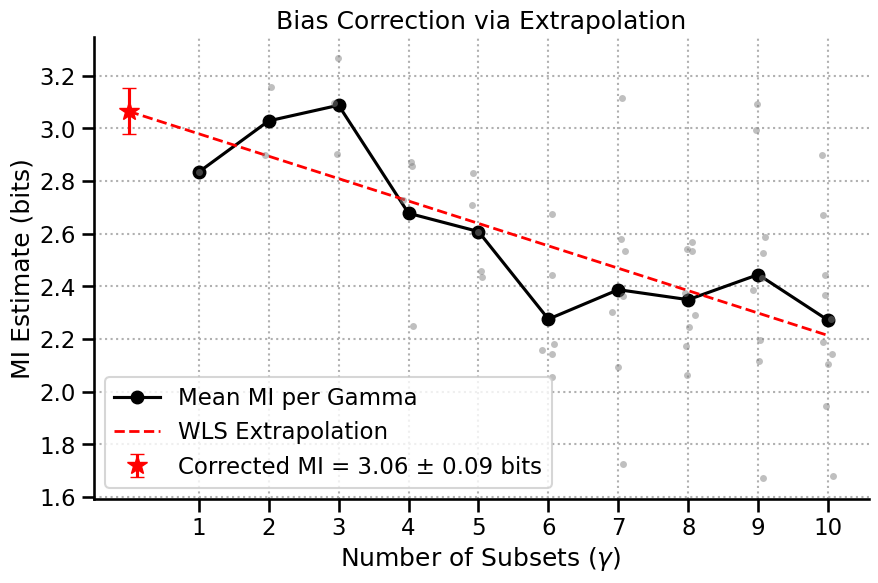

<Figure size 640x480 with 0 Axes>

In [5]:
ax = rigorous_results.plot(show=False) # if you want to customize the plot, set show=False and then call plt.show() after customizing

# Annotate with ground truth
ax.axhline(
    y=ground_truth_mi,
    color='green', linestyle='-', linewidth=2,
    label=f'Ground truth ({ground_truth_mi:.2f} bits)'
)

# Annotate with naive estimate on full data
ax.axhline(
    y=naive_full,
    color='orange', linestyle='--', linewidth=2,
    label=f'Naive estimate on full N ({naive_full:.3f} bits)'
)

ax.set_ylim(0, max(ground_truth_mi * 1.2, mi_corrected + mi_error * 2))
ax.legend()
plt.tight_layout()
plt.show()

The green line shows the ground truth. The red star — the bias-corrected estimate
— should sit close to it. The orange dashed line shows where the naive full-data
estimate lands; in this run it falls a little *below* the truth, and the
extrapolation pulls the estimate back toward 3.0. On a different run or dataset
the naive point could sit above instead — the correction does not assume a
direction, it simply follows the systematic $\gamma$-trend.

The slope of the red fit line tells you how strong the finite-sample dependence
was: a steeper slope means the estimate was more sensitive to sample size, which
usually indicates a harder problem (higher-dimensional, lower SNR, or a more
complex relationship between X and Y).

You may also have seen warnings during the run that some high-$\gamma$ subsets
fell below the library's reliable-sample threshold — with $N = 2000$ and $\gamma$
up to 10, the smallest subsets hold only 200 samples. That is the library being
appropriately cautious about its noisiest points; here the fit still passed its
checks (`is_reliable=True`), but on a harder problem those small-subset points are
exactly the ones that can break the extrapolation.

The `is_reliable` flag is `True` when the library found at least
`min_gamma_points` (default 5) $\gamma$ values in the linear region of the curve.
If the curve is strongly non-linear (e.g. it bends sharply and then flattens), the
linear extrapolation is not trustworthy and `is_reliable` will be `False`. Not
every dataset yields a reliable rigorous result: with very little data, or an
extremely complex X–Y relationship, the finite-sample deviation stops behaving as
$O(1/N)$ across the range and the extrapolation is not valid.

When `is_reliable=False`, you have two options:

1. **Collect more data.** The most principled solution. The bias correction
   works best when you have enough samples that the estimator is operating
   in a regime where bias scales linearly with $1/N$.

2. **Simplify the model.** A very large or complex network can produce
   a strongly non-linear bias curve. Try reducing `hidden_dim`, `embedding_dim`,
   or `n_layers`, and re-run. This could work, but likely won't change the answer if you truly
   don't have enough data. A good rule of thumb is that we need to sample the low dimensional
   space well enough, so if we think we have ~10 dims (usually we don't) then we need a handful times
   as much samples, i.e., 500 samples.

In all cases: **do not report an unreliable estimate as a scientific result.**
The `is_reliable` flag exists precisely to prevent this. Treat it as a hard
gate — if it is `False`, the number should not appear in a paper without
substantial caveats.

## 5. Fine-Tuning the Rigorous Analysis

For most datasets, the defaults work well. For advanced users, three
parameters control the bias correction procedure:

- **`gamma_range`** (default `range(1, 11)`): the range of $\gamma$ values
  to test. A wider range gives more points for the linear fit but trains on
  very small subsets at high $\gamma$. A narrower range is more stable for
  small datasets.

- **`delta_threshold`** (default `0.1`): the maximum curvature allowed for
  a $\gamma$ point to be included in the linear region. Lower values are
  stricter — fewer points are included, but the fit is more linear. If
  `is_reliable=False`, try increasing this slightly.

- **`min_gamma_points`** (default `5`): the minimum number of $\gamma$ points
  required in the linear region for the fit to be considered reliable.
  Reducing this to 3 or 4 may rescue a borderline unreliable result, but
  at the cost of a less stable extrapolation.

- **`confidence_level`** (default `0.68`): the width of the confidence
  interval. `0.68` corresponds to $1\sigma$ (one standard deviation).
  Use `0.95` for a $2\sigma$ interval in contexts where that convention
  is expected.

## 7. Key Takeaways

- **`mode='estimate'` is unreliable on limited data.** Finite-sample MI estimates
  are systematically off: a classical upward pull (spurious dependence) competes
  with a downward pull (an under-trained lower-bound critic), and both grow as the
  sample size shrinks. This is not a bug — it is a fundamental property of
  estimation from limited data.

- **`mode='rigorous'` corrects for this** by extrapolating the MI-vs-$\gamma$
  curve to the infinite-data limit — in whichever direction the trend runs — and
  it returns a bias-corrected estimate with a confidence interval.

- **`mode='rigorous'` runs 55 training runs by default** (1 + 2 + … + 10).
  Always use `n_workers > 1` to parallelise.

- **`is_reliable` is a hard gate.** If it is `False`, the correction is not
  trustworthy. Collect more data, simplify the model, or adjust `gamma_range`
  before reporting any result.

- **The recommended workflow is: sweep → rigorous.**
  Use `mode='sweep'` (Tutorial 4) to find good parameters, then use
  `mode='rigorous'` with those parameters for the final estimate.

- **For IID data, use `Split(mode='random')`.** For any continuous recording,
  use `Split(mode='blocked')`. This applies to `mode='rigorous'` just as it
  applies to `mode='estimate'`.

## Common Mistakes

1. **Running `mode='rigorous'` with `n_workers=1`.** With 55 training runs,
   sequential execution is very slow. Always set `n_workers` to the number of
   available CPU cores. On a modern laptop, `n_workers=4` is a reasonable default.

2. **Reporting a result when `is_reliable=False`.** The `is_reliable` flag
   is not a suggestion — it is a validity check. An unreliable rigorous estimate
   can be *more* wrong than a naive estimate, because the extrapolation is being
   applied outside its valid range. Always check this flag before reporting.

3. **Using `mode='rigorous'` without first running a sweep.** Rigorous mode
   uses whatever architecture you specify via the `Model` / `Training` configs. If the architecture
   is too small to capture the relationship, the rigorous estimate will be
   corrected but still low. Run a sweep first (Tutorial 4) to confirm that
   the architecture saturates.

4. **Interpreting the confidence interval as the total uncertainty.**
   The confidence interval from `mode='rigorous'` reflects the uncertainty of
   the linear extrapolation fit. It does not capture model uncertainty or the
   possibility that the architecture is underfitting. The two sources of
   uncertainty are complementary — use the sweep to address the latter.

## What's Next

We now have a complete workflow for reliable MI estimation: format your data
correctly (Tutorial 2), choose the right split mode (Tutorial 3), find good
parameters with a sweep (Tutorial 4), and correct for bias with rigorous
estimation (Tutorial 5).

In **Tutorial 6**, we move from asking "how much information is shared?" to
asking "when is it shared, and in which direction?" We introduce three
temporally-oriented analysis modes: `mode='lag'` to find transmission delays,
`mode='precision'` to measure the timescale of spike-timing codes, and
`mode='transfer'` to estimate directed information flow between brain regions.